# Kinematic Convergence Test — both frozen axes on one shared stream

Stress test: run the frozen `activity_state` and `movement_regularity` rulepacks on a single MotionSense pocket accelerometer stream, to measure what does not transfer across placement (chest -> pocket). Nothing is re-derived or re-tuned; transfer failures are logged, not fixed.

## Setup
- Shared stream: MotionSense (front trouser pocket, 50 Hz, gravity-removed `userAcceleration`, in g). Both axes consume the same samples.
- No gyroscope is used from this stream, so `activity_state`'s cycling branch is inactive.
- Two windowings off the same samples: `activity_state` 2.56 s / 128 / 50%; `movement_regularity` 5 s / 250 / 50%.
- Subject-independent: held-out MotionSense subjects only.
- Both rulepacks are reproduced verbatim from their notebooks and frozen.

## 1. Setup and configuration
Frozen parameters copied verbatim from each axis. Do not retune.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

mpl.rcParams.update({"figure.figsize": (7.0, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.titlesize": 12, "axes.labelsize": 11,
                     "font.size": 11, "legend.fontsize": 10})

In [2]:
SAMPLE_RATE = 50

# Shared stream
MS_ROOT = "/home/voare/Documents/Synheart/Kinematics/Dataset/MotionSense/A_DeviceMotion_data/A_DeviceMotion_data"
MS_LABELS = {"sit": "sedentary", "std": "standing", "wlk": "walking", "jog": "running"}
HELD_OUT_SUBJ = {19, 20, 21, 22, 23, 24}

# FROZEN -- activity_state rulepack (verbatim; magnitude features in g)
AS_WINDOW, AS_STEP = 128, 64
T_STILL, T_RUN = 0.10, 1.00
BAND_LO, BAND_HI, CAD_RUN = 0.77, 1.07, 1.20

# FROZEN -- movement_regularity rulepack (verbatim; constants set on PAMAP2 chest, m/s^2)
R_WINDOW, R_STEP = 250, 125
LAG_MIN, LAG_MAX, PEAK_PROMINENCE = 10, 100, 0.05
MOVEMENT_FLOOR = 0.5                  # chest m/s^2 -- applied unchanged to gravity-removed g here
ACC_MAX = 16 * 9.81
MAX_BAD_FRAC = 0.5
MIN_CYCLES, SAT_CYCLES, PROM_FULL = 7.0, 10.0, 1.5

## 2. Shared MotionSense stream and dual windowing
Load held-out subjects; each file is one continuous activity. The magnitude of `userAcceleration` is the single stream both axes window.

In [3]:
streams = []   # (activity, subject, magnitude array)
for folder in sorted(os.listdir(MS_ROOT)):
    code_ = folder.split("_")[0]
    if code_ not in MS_LABELS:
        continue
    for f in glob.glob(f"{MS_ROOT}/{folder}/sub_*.csv"):
        subj = int(os.path.basename(f)[4:-4])
        if subj not in HELD_OUT_SUBJ:
            continue
        d = pd.read_csv(f)
        mag = np.sqrt(d["userAcceleration.x"]**2 + d["userAcceleration.y"]**2 + d["userAcceleration.z"]**2).to_numpy()
        streams.append((MS_LABELS[code_], subj, mag))
print(f"streams: {len(streams)} (held-out subjects {sorted(HELD_OUT_SUBJ)})")
print(pd.Series([a for a, _, _ in streams]).value_counts().to_string())

streams: 54 (held-out subjects [19, 20, 21, 22, 23, 24])
walking      18
running      12
sedentary    12
standing     12


## 3. Frozen rules (verbatim)
The two rulepacks copied exactly from their notebooks. No parameter is changed here.

In [4]:
# --- activity_state (verbatim): cadence by argmax over the [10,64] lag band, then the energy + cadence rule ---
def as_cadence(w):
    m = w - w.mean()
    ac = np.correlate(m, m, mode="full")[len(m)-1:]
    if ac[0] == 0:
        return np.nan
    ac = ac / ac[0]
    return SAMPLE_RATE / (10 + int(np.argmax(ac[10:64])))

def activity_rule(movement, mean_mag, cad):
    if movement < T_STILL:
        return "sedentary"
    if BAND_LO <= mean_mag <= BAND_HI:                 # walk/run overlap band -> cadence tiebreaker
        return "running" if cad >= CAD_RUN else "walking"
    return "running" if mean_mag >= T_RUN else "walking"

In [5]:
# --- movement_regularity (verbatim): unbiased autocorrelation, first dominant peak, gates ---
def fill_gaps(mag, bad):
    mag = mag.copy()
    for i in range(1, len(mag)):
        if bad[i]:
            mag[i] = mag[i-1]
    return mag

def regularity_detail(mag):
    x = mag - mag.mean()
    n = len(x)
    ac = np.correlate(x, x, mode="full")[n-1:n+LAG_MAX] / (n - np.arange(LAG_MAX + 1))   # unbiased
    if ac[0] <= 0:
        return np.nan, np.nan, np.nan
    ac = ac / ac[0]
    peaks, props = find_peaks(ac, prominence=PEAK_PROMINENCE)
    keep = (peaks >= LAG_MIN) & (peaks <= LAG_MAX)
    peaks, proms = peaks[keep], props["prominences"][keep]
    if len(peaks) == 0:
        return 0.0, np.nan, 0.0
    lag = int(peaks[0])
    return float(np.clip(ac[lag], 0.0, 1.0)), lag, float(proms[0])

def reg_emit(window):
    """Return (movement, score, dom_lag, reason) for a 250-sample magnitude window."""
    bad = np.isnan(window) | (window > ACC_MAX)
    if bad.mean() > MAX_BAD_FRAC or bad[0]:
        return np.nan, np.nan, np.nan, "window_unreliable"
    mag = fill_gaps(window, bad)
    movement = float(mag.std())
    score, lag, prom = regularity_detail(mag)
    n_cycles = R_WINDOW / lag if lag == lag else 0.0
    if movement < MOVEMENT_FLOOR:
        reason = "low_movement"
    elif n_cycles < MIN_CYCLES:
        reason = "insufficient_cycles"
    else:
        reason = "valid"
    return movement, score, lag, reason

## 4. Part A — movement_regularity chest -> pocket transfer (frozen rulepack)
Frozen regularity on the pocket stream: per-activity score, the rank-ordering, and the unit check on `MOVEMENT_FLOOR`. This is the before state.

In [6]:
recs = []
for activity, subj, mag in streams:
    for s in range(0, len(mag) - R_WINDOW + 1, R_STEP):
        mv, score, lag, reason = reg_emit(mag[s:s+R_WINDOW])
        recs.append((activity, subj, mv, score, lag, reason))
A = pd.DataFrame(recs, columns=["activity", "subject", "movement_g", "score", "dom_lag", "reason"])

print("regularity SCORE per activity (computable windows). PAMAP2 chest reference: walking/running ~0.93.")
print(A.dropna(subset=["score"]).groupby("activity")["score"].agg(["count", "median"]).round(3).to_string())
med = A.dropna(subset=["score"]).groupby("activity")["score"].median()
print()
print("rank-ordering (expect walking/running > sitting/standing):")
print(f"  walking {med.get('walking', np.nan):.3f}, running {med.get('running', np.nan):.3f}"
      f"  vs  sedentary {med.get('sedentary', np.nan):.3f}, standing {med.get('standing', np.nan):.3f}")
print()
print(f"movement std (g) per activity vs MOVEMENT_FLOOR = {MOVEMENT_FLOOR} (chest m/s^2 applied to g):")
print(A.groupby("activity")["movement_g"].median().round(3).to_string())
print()
print("emission reason share per activity:")
print(pd.crosstab(A["activity"], A["reason"], normalize="index").round(2).to_string())

regularity SCORE per activity (computable windows). PAMAP2 chest reference: walking/running ~0.93.
           count  median
activity                
running      263   0.181
sedentary    597   0.227
standing     655   0.191
walking      670   0.000

rank-ordering (expect walking/running > sitting/standing):
  walking 0.000, running 0.181  vs  sedentary 0.227, standing 0.191

movement std (g) per activity vs MOVEMENT_FLOOR = 0.5 (chest m/s^2 applied to g):
activity
running      0.772
sedentary    0.004
standing     0.010
walking      0.368

emission reason share per activity:
reason     low_movement  valid
activity                      
running            0.05   0.95
sedentary          1.00   0.00
standing           1.00   0.00
walking            0.74   0.26


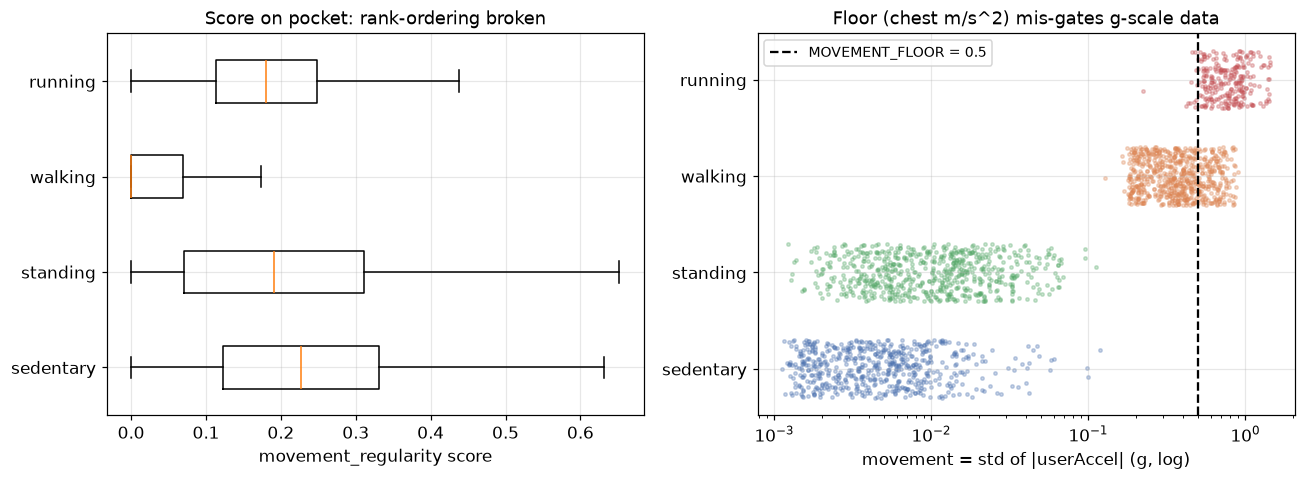

In [7]:
order = ["sedentary", "standing", "walking", "running"]
colors = {"sedentary": "#4C72B0", "standing": "#55A868", "walking": "#DD8452", "running": "#C44E52"}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].boxplot([A.loc[(A.activity == a) & A.score.notna(), "score"].to_numpy() for a in order],
              orientation="horizontal", tick_labels=order, showfliers=False)
ax[0].set_xlabel("movement_regularity score")
ax[0].set_title("Score on pocket: rank-ordering broken")

jit = np.random.default_rng(0)
for i, a in enumerate(order):
    sub = A[A.activity == a]
    ax[1].scatter(sub["movement_g"], i + jit.uniform(-0.3, 0.3, len(sub)), s=5, alpha=0.3, color=colors[a])
ax[1].axvline(MOVEMENT_FLOOR, ls="--", color="black", label=f"MOVEMENT_FLOOR = {MOVEMENT_FLOOR}")
ax[1].set_yticks(range(len(order))); ax[1].set_yticklabels(order)
ax[1].set_xscale("log"); ax[1].set_xlabel("movement = std of |userAccel| (g, log)")
ax[1].set_title("Floor (chest m/s^2) mis-gates g-scale data"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. Part B — cross-axis agreement (frozen rulepack)
Both windowings off the same samples; each 5 s regularity window is mapped to the overlapping `activity_state` label(s) by majority. This is the before state.

In [8]:
pairs = []
for activity, subj, mag in streams:
    AS = [(s, activity_rule(mag[s:s+AS_WINDOW].std(), mag[s:s+AS_WINDOW].mean(), as_cadence(mag[s:s+AS_WINDOW])))
          for s in range(0, len(mag) - AS_WINDOW + 1, AS_STEP)]
    for s in range(0, len(mag) - R_WINDOW + 1, R_STEP):
        mv, score, lag, reason = reg_emit(mag[s:s+R_WINDOW])
        overlap = [p for st, p in AS if st < s + R_WINDOW and st + AS_WINDOW > s]
        as_label = max(set(overlap), key=overlap.count) if overlap else None
        pairs.append((activity, as_label, reason, score))
P = pd.DataFrame(pairs, columns=["true", "as_label", "reg_reason", "reg_score"])

moving = P[P["as_label"].isin(["walking", "running"])]
still = P[P["as_label"] == "sedentary"]
print("activity_state pred vs true activity (home-turf sanity):")
print(pd.crosstab(P["true"], P["as_label"]).to_string())
print()
print(f"activity_state = walking/running  ({len(moving)} windows)  [expect regularity valid + high]")
print("   regularity reason:", moving["reg_reason"].value_counts(normalize=True).round(2).to_dict())
hi = (moving["reg_reason"] == "valid") & (moving["reg_score"] >= 0.7)
print(f"   valid AND score >= 0.7: {hi.mean():.2f}  ->  disagreements: {(~hi).sum()} of {len(moving)}")
print()
print(f"activity_state = sedentary  ({len(still)} windows)  [expect regularity null low_movement]")
print("   regularity reason:", still["reg_reason"].value_counts(normalize=True).round(2).to_dict())
print(f"   null as low_movement: {(still['reg_reason'] == 'low_movement').mean():.2f}")

activity_state pred vs true activity (home-turf sanity):
as_label   running  sedentary  walking
true                                  
running        258          0        5
sedentary        0        597        0
standing         0        655        0
walking         54          0      616

activity_state = walking/running  (933 windows)  [expect regularity valid + high]
   regularity reason: {'low_movement': 0.55, 'valid': 0.45}
   valid AND score >= 0.7: 0.00  ->  disagreements: 933 of 933

activity_state = sedentary  (1252 windows)  [expect regularity null low_movement]
   regularity reason: {'low_movement': 1.0}
   null as low_movement: 1.00


## 6. Normalization — placement adaptation
The autocorrelation method and the score definition are unchanged. Only the two placement-broken steps are adapted: the movement-floor units and the dominant-period selection. `MIN_CYCLES` follows as a unit consequence of the period change. The PAMAP2 validation and `activity_state` notebooks are untouched.

In [9]:
# FIX 1: express the movement floor in the stream's units (gravity-removed g), not chest m/s^2.
MOVEMENT_FLOOR_G = MOVEMENT_FLOOR / 9.81        # 0.5 m/s^2 -> ~0.051 g

# FIX 2: select the dominant period by argmax over the lag band -- the same selection activity_state
# uses on this stream -- instead of the first autocorrelation peak; read the score at that period.
# Consequence: the selected period is the stride (~lag 55) on pocket, not the step (~lag 27) on chest,
# so the cycle-adequacy minimum is the 3.5-stride literature value expressed in stride-periods.
MIN_CYCLES_STRIDE = 3.5

def reg_emit_adapted(window):
    bad = np.isnan(window) | (window > ACC_MAX)
    if bad.mean() > MAX_BAD_FRAC or bad[0]:
        return np.nan, np.nan, np.nan, "window_unreliable"
    mag = fill_gaps(window, bad)
    movement = float(mag.std())
    x = mag - mag.mean(); n = len(x)
    ac = np.correlate(x, x, mode="full")[n-1:n+LAG_MAX] / (n - np.arange(LAG_MAX + 1))   # unbiased, unchanged
    if ac[0] <= 0:
        score, lag = np.nan, np.nan
    else:
        ac = ac / ac[0]
        lag = LAG_MIN + int(np.argmax(ac[LAG_MIN:LAG_MAX + 1]))    # FIX 2: argmax dominant period
        score = float(np.clip(ac[lag], 0.0, 1.0))
    n_cycles = R_WINDOW / lag if lag == lag else 0.0
    if movement < MOVEMENT_FLOOR_G:
        reason = "low_movement"
    elif n_cycles < MIN_CYCLES_STRIDE:
        reason = "insufficient_cycles"
    else:
        reason = "valid"
    return movement, score, lag, reason

print(f"FIX 1 floor: {MOVEMENT_FLOOR} m/s^2 -> {MOVEMENT_FLOOR_G:.3f} g")
print(f"FIX 2 period selection: argmax over [{LAG_MIN},{LAG_MAX}] (shared with activity_state)")
print(f"MIN_CYCLES: 7 step-periods (chest) -> {MIN_CYCLES_STRIDE} stride-periods (pocket)")

FIX 1 floor: 0.5 m/s^2 -> 0.051 g
FIX 2 period selection: argmax over [10,100] (shared with activity_state)
MIN_CYCLES: 7 step-periods (chest) -> 3.5 stride-periods (pocket)


Part A after: regularity score median, frozen vs adapted (the rank-ordering flip):
           score_before  score_after
activity                            
walking           0.000        0.711
running           0.181        0.656
standing          0.191        0.314
sedentary         0.227        0.294

emission reason share per activity (adapted):
reason     insufficient_cycles  low_movement  valid
activity                                           
running                   0.10          0.00   0.90
sedentary                 0.00          0.99   0.01
standing                  0.00          0.96   0.04
walking                   0.01          0.00   0.99


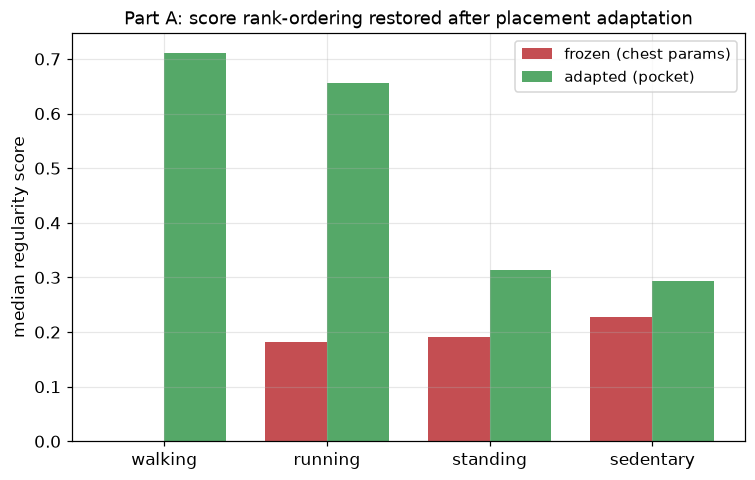

In [10]:
recs2 = []
for activity, subj, mag in streams:
    for s in range(0, len(mag) - R_WINDOW + 1, R_STEP):
        mv, score, lag, reason = reg_emit_adapted(mag[s:s+R_WINDOW])
        recs2.append((activity, mv, score, reason))
A2 = pd.DataFrame(recs2, columns=["activity", "movement_g", "score", "reason"])

before = A.dropna(subset=["score"]).groupby("activity")["score"].median()
after = A2.dropna(subset=["score"]).groupby("activity")["score"].median()
flip = pd.DataFrame({"score_before": before, "score_after": after}).round(3).reindex(["walking", "running", "standing", "sedentary"])
print("Part A after: regularity score median, frozen vs adapted (the rank-ordering flip):")
print(flip.to_string())
print()
print("emission reason share per activity (adapted):")
print(pd.crosstab(A2["activity"], A2["reason"], normalize="index").round(2).to_string())

x = np.arange(len(flip)); w = 0.38
plt.figure(figsize=(7, 4.5))
plt.bar(x - w/2, flip["score_before"], w, label="frozen (chest params)", color="#C44E52")
plt.bar(x + w/2, flip["score_after"], w, label="adapted (pocket)", color="#55A868")
plt.xticks(x, flip.index); plt.ylabel("median regularity score")
plt.title("Part A: score rank-ordering restored after placement adaptation")
plt.legend(); plt.tight_layout(); plt.show()

In [11]:
pairs2 = []
for activity, subj, mag in streams:
    AS = [(s, activity_rule(mag[s:s+AS_WINDOW].std(), mag[s:s+AS_WINDOW].mean(), as_cadence(mag[s:s+AS_WINDOW])))
          for s in range(0, len(mag) - AS_WINDOW + 1, AS_STEP)]
    for s in range(0, len(mag) - R_WINDOW + 1, R_STEP):
        mv, score, lag, reason = reg_emit_adapted(mag[s:s+R_WINDOW])
        overlap = [p for st, p in AS if st < s + R_WINDOW and st + AS_WINDOW > s]
        as_label = max(set(overlap), key=overlap.count) if overlap else None
        pairs2.append((as_label, reason, score))
P2 = pd.DataFrame(pairs2, columns=["as_label", "reg_reason", "reg_score"])

mov = P2[P2["as_label"].isin(["walking", "running"])]
still = P2[P2["as_label"] == "sedentary"]
valid = mov["reg_reason"] == "valid"
regular = valid & (mov["reg_score"] >= 0.5)
print("Part B after: cross-axis agreement")
print(f"activity_state = walking/running ({len(mov)} windows)   [before: 0 valid+high of {len(mov)}]")
print("   regularity reason:", mov["reg_reason"].value_counts(normalize=True).round(2).to_dict())
print(f"   valid: {valid.mean():.2f} | valid AND regular (score >= 0.5): {regular.mean():.2f} | median valid score: {mov.loc[valid, 'reg_score'].median():.3f}")
print(f"activity_state = sedentary ({len(still)} windows): null low_movement {(still['reg_reason'] == 'low_movement').mean():.2f}")

Part B after: cross-axis agreement
activity_state = walking/running (933 windows)   [before: 0 valid+high of 933]
   regularity reason: {'valid': 0.97, 'insufficient_cycles': 0.03}
   valid: 0.97 | valid AND regular (score >= 0.5): 0.90 | median valid score: 0.698
activity_state = sedentary (1252 windows): null low_movement 0.97


## 7. Transfer ledger (post-fix)

In [12]:
ledger = pd.DataFrame([
    ["T_STILL / T_RUN / cadence split", "activity_state / pocket",        "survived (home turf)", "derived on MotionSense; not an out-of-placement test"],
    ["MOVEMENT_FLOOR",                  "movement_regularity / chest m/s^2","fixed",                "FIX 1: expressed in g (0.5 m/s^2 -> 0.051 g); walking no longer nulled (~74% -> ~0%)"],
    ["dominant-period selection",       "movement_regularity / chest",     "fixed",                "FIX 2: argmax over the lag band (shared with activity_state) not first-peak; reads the stride, not a sub-harmonic"],
    ["MIN_CYCLES",                      "movement_regularity / chest",     "fixed",                "unit consequence of FIX 2: 3.5 stride-periods on pocket (was 7 step-periods on chest)"],
    ["placement transfer (period + floor)","chest -> pocket",             "proven",               "score rank-ordering and cross-axis agreement restored on held-out subjects"],
    ["spectrum on pocket (rhythmic vs irregular motion)","own-phone data","owed",                 "MotionSense has no irregular-but-moving activity; only rhythmic > still is shown here"],
], columns=["item", "scope", "status", "note"])
print(ledger.to_string(index=False))

                                             item                             scope               status                                                                                                              note
                  T_STILL / T_RUN / cadence split           activity_state / pocket survived (home turf)                                                              derived on MotionSense; not an out-of-placement test
                                   MOVEMENT_FLOOR movement_regularity / chest m/s^2                fixed                              FIX 1: expressed in g (0.5 m/s^2 -> 0.051 g); walking no longer nulled (~74% -> ~0%)
                        dominant-period selection       movement_regularity / chest                fixed FIX 2: argmax over the lag band (shared with activity_state) not first-peak; reads the stride, not a sub-harmonic
                                       MIN_CYCLES       movement_regularity / chest                fixed                    

### Findings
- **Two placement-transfer breaks fixed (in this notebook only; the PAMAP2 validation and `activity_state` notebooks are untouched):**
  - FIX 1 — `MOVEMENT_FLOOR` expressed in the stream's units (g): walking is no longer nulled (~74% -> ~0%); sit/stand still null correctly.
  - FIX 2 — dominant period selected by argmax over the lag band (the selection `activity_state` already uses on this stream) instead of the first autocorrelation peak: the score reads the stride fundamental (~lag 55), not a sub-stride harmonic (~lag 14).
- `MIN_CYCLES` is a unit consequence of FIX 2: the selected period is the stride on pocket (vs the step on chest), so the 3.5-stride literature minimum is 3.5 stride-periods (was 7 step-periods). No other constant changed.
- **Proof (held-out subjects):** the score rank-ordering inverts back to correct — walking 0.000 -> 0.711, running 0.181 -> 0.656, both now above sedentary (0.294) and standing (0.314). Cross-axis: where `activity_state` says walking/running, regularity is now ~97% valid (was 0%) and ~90% valid with a regular score (>= 0.5); where it says sedentary, regularity still nulls `low_movement` (~97%).
- **Scope / honesty:** this proves **placement transfer** (chest -> pocket period selection + floor units), **not spectrum-on-pocket**. MotionSense has no irregular-but-moving activities (no vacuuming / fidgeting), so it confirms only rhythmic > still, not rhythmic > irregular-motion. Spectrum validation on pocket remains owed to own-phone data — kept as a separate ledger line.
- Still-activity scores (~0.3) are spurious noise-autocorrelation that argmax surfaces, but they are gated by the movement floor and never emitted.
- Cycling still could not be tested (no gyroscope in this stream). Nothing else re-tuned; subject-independent split.

# Convergence Test v2 — three frozen axes on one shared stream

Extends the test above to **three** frozen kinematic rulepacks — `activity_state`, `movement_regularity`, `postural_state` — on one shared MotionSense pocket stream. Same stress-test rules: every rulepack is frozen as shipped, nothing is re-derived, and a broken threshold is recorded as a finding, not fixed. Fixes belong to a later per-placement-normalization loop against own-phone data.

## v2 setup
- Each axis is told explicitly which stream it consumes:
  - `activity_state` and `movement_regularity` consume the magnitude of `userAcceleration` (gravity-removed, g) — the same single stream as the v1 test above.
  - `postural_state` needs gravity (it is the signal). MotionSense Core Motion ships a `gravity` vector and `userAcceleration` separately; the raw accelerometer is reconstructed as `total = gravity + userAcceleration` (in g) and fed to the frozen postural rule, mirroring PAMAP2's raw chest accel.
- Windows: `activity_state` 2.56 s (128); `movement_regularity` 5 s (250); `postural_state` 5 s (250). All 50% overlap at 50 Hz.
- `movement_regularity` uses the **normalized pocket version** from the v1 test (floor in g, dominant-period argmax), not the chest-broken one.
- Subject-independent: the same held-out MotionSense subjects as the v1 test.
- MotionSense has no lying activity, so postural's core lying-vs-upright distinction is untestable here (flagged as owed).

## v2.1 Configuration — postural frozen params + shared windowing
Frozen postural rulepack copied verbatim. `activity_state` and the adapted `movement_regularity` constants are reused from the cells above (`AS_*`, `R_*`, `MOVEMENT_FLOOR_G`, `MIN_CYCLES_STRIDE`); none is changed.

In [13]:
import json

# FROZEN -- postural_state rulepack (verbatim from postural_state.ipynb)
P_WINDOW, P_STEP = 250, 125          # 5 s / 50% at 50 Hz (postural shipped 5 s; same as regularity)
MOVE_T = 1.0                          # std of |accel| above this -> in_motion. Chest m/s^2 (UNIT MISMATCH vs g here).
TILT_T = 65.0                         # tilt (deg) from calibrated "up": above -> lying, below -> upright
CALIB_LABEL = "standing"             # postural calibrates "up" from labeled standing (MotionSense has it)
POSTURE_CATEGORIES = ["lying", "upright", "in_motion"]
HSI_CATEGORIES = ["sedentary", "standing", "walking", "running", "cycling", "vigorous"]   # frozen from activity_state

# sanity: the two reused rulepacks are already defined above and stay frozen
assert "activity_rule" in dir() and "reg_emit_adapted" in dir(), "run the v1 cells above first (frozen rules)"
print(f"postural frozen: WINDOW={P_WINDOW}/{P_STEP}, MOVE_T={MOVE_T} (chest m/s^2), TILT_T={TILT_T} deg, calib={CALIB_LABEL}")
print(f"reused frozen: activity_state {AS_WINDOW}/{AS_STEP}; movement_regularity {R_WINDOW}/{R_STEP} "
      f"(floor {MOVEMENT_FLOOR_G:.3f} g, MIN_CYCLES {MIN_CYCLES_STRIDE})")

postural frozen: WINDOW=250/125, MOVE_T=1.0 (chest m/s^2), TILT_T=65.0 deg, calib=standing
reused frozen: activity_state 128/64; movement_regularity 250/125 (floor 0.051 g, MIN_CYCLES 3.5)


## v2.2 Shared front end (three axes)
One pass over the held-out subjects builds both streams off the same samples: the `userAcceleration` magnitude (for `activity_state` and `movement_regularity`) and the reconstructed raw accel `total = gravity + userAcceleration` (for `postural_state`). Each file is one continuous activity.

In [14]:
streams3 = []   # (activity, subject, mag_userAccel[g], total_accel_xyz[g])
for folder in sorted(os.listdir(MS_ROOT)):
    code_ = folder.split("_")[0]
    if code_ not in MS_LABELS:
        continue
    for f in glob.glob(f"{MS_ROOT}/{folder}/sub_*.csv"):
        subj = int(os.path.basename(f)[4:-4])
        if subj not in HELD_OUT_SUBJ:
            continue
        d = pd.read_csv(f)
        ua = d[["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]].to_numpy()
        gr = d[["gravity.x", "gravity.y", "gravity.z"]].to_numpy()    # Core Motion gravity (g, ~unit vector)
        mag = np.sqrt((ua ** 2).sum(axis=1))                          # activity_state + movement_regularity stream
        total = gr + ua                                               # postural stream (raw accel reconstruction)
        streams3.append((MS_LABELS[code_], subj, mag, total))

print(f"streams: {len(streams3)} (held-out subjects {sorted(HELD_OUT_SUBJ)})")
print(pd.Series([a for a, _, _, _ in streams3]).value_counts().to_string())
print("\nstream consumed per axis:")
print("  activity_state, movement_regularity : |userAcceleration|  (gravity-removed, g)")
print("  postural_state                      : gravity + userAcceleration  (raw accel, g)")
still = next(t for a, s, m, t in streams3 if a == "standing")           # a still stream: |raw accel| ~ 1 g
print(f"raw-accel magnitude on a standing stream: mean {np.linalg.norm(still, axis=1).mean():.3f} g "
      f"(chest PAMAP2 was ~9.81 m/s^2 -- the MOVE_T unit gap)")

streams: 54 (held-out subjects [19, 20, 21, 22, 23, 24])
walking      18
running      12
sedentary    12
standing     12

stream consumed per axis:
  activity_state, movement_regularity : |userAcceleration|  (gravity-removed, g)
  postural_state                      : gravity + userAcceleration  (raw accel, g)
raw-accel magnitude on a standing stream: mean 1.005 g (chest PAMAP2 was ~9.81 m/s^2 -- the MOVE_T unit gap)


## v2.3 Frozen postural rule (verbatim)
`gravity_vector`, `tilt_angle`, `window_posture` copied exactly from `postural_state.ipynb`. No parameter is changed.

In [15]:
def gravity_vector(window_xyz):
    """Mean accelerometer over the window ~ gravity direction when still."""
    return window_xyz.mean(axis=0)

def tilt_angle(g, up):
    """Angle (deg) between two vectors; gravity-now vs the calibrated upright reference."""
    g = g / (np.linalg.norm(g) + 1e-9)
    up = up / (np.linalg.norm(up) + 1e-9)
    return np.degrees(np.arccos(np.clip(g @ up, -1.0, 1.0)))

def window_posture(window_xyz, up):
    """Return (movement, tilt, label) for one window. up = subject's standing gravity vector."""
    movement = float(np.sqrt((window_xyz ** 2).sum(axis=1)).std())
    tilt = float(tilt_angle(gravity_vector(window_xyz), up))
    if movement > MOVE_T:
        label = "in_motion"
    else:
        label = "upright" if tilt < TILT_T else "lying"
    return movement, tilt, label

## v2.4 Postural chest -> pocket transfer (frozen)
The main new question. Calibrate "up" from MotionSense standing windows, then run the frozen rule on the pocket stream. Three things are measured and recorded, not fixed: whether the pocket "up" vector is sensible, whether `TILT_T = 65 deg` still means lying-vs-upright, and the `MOVE_T` unit mismatch (chest m/s^2 vs g).

In [16]:
# Calibration: "up" per subject = mean reconstructed accel over that subject's standing windows.
up_by_subj, calib_rows = {}, []
for activity, subj, mag, total in streams3:
    if activity != CALIB_LABEL:
        continue
    up_by_subj.setdefault(subj, []).append(total)
for subj in sorted(up_by_subj):
    allt = np.vstack(up_by_subj[subj])
    up = allt.mean(axis=0)
    spread = np.array([tilt_angle(g, up) for g in allt[::20]])          # within-standing stability
    up_by_subj[subj] = up
    calib_rows.append((subj, up.round(2), round(float(np.linalg.norm(up)), 3),
                       round(float(np.median(spread)), 1), round(float(np.percentile(spread, 95)), 1)))
cal = pd.DataFrame(calib_rows, columns=["subject", "up_vector", "|up|_g", "within_std_med_deg", "within_std_95_deg"])
print("Per-subject pocket 'up' (from standing). |up| ~ 1 g (chest was ~9.81 m/s^2); tilt normalizes, so magnitude is harmless.")
print(cal.to_string(index=False))

ks = sorted(up_by_subj)
cross = [tilt_angle(up_by_subj[ks[i]], up_by_subj[ks[j]]) for i in range(len(ks)) for j in range(i + 1, len(ks))]
print(f"\ncross-subject 'up' angle: median {np.median(cross):.1f} deg, range {min(cross):.1f}-{max(cross):.1f} deg")
print("=> stable WITHIN a subject (small within-standing spread) but NOT a shared vector: 'up' points along the")
print("   thigh (phone in pocket), not the torso. Per-subject self-calibration is sensible; a global up is not.")

Per-subject pocket 'up' (from standing). |up| ~ 1 g (chest was ~9.81 m/s^2); tilt normalizes, so magnitude is harmless.
 subject            up_vector  |up|_g  within_std_med_deg  within_std_95_deg
      19  [-0.39, 0.93, 0.04]   1.007                 3.7                7.9
      20  [-0.1, 0.99, -0.07]   0.998                 4.1               13.1
      21 [-0.15, 0.99, -0.03]   1.000                 5.3               13.9
      22 [-0.05, 0.99, -0.13]   1.002                 5.5               15.0
      23     [0.03, 1.0, 0.0]   1.001                 2.1                9.0
      24  [-0.04, 0.99, -0.1]   0.996                 6.4               16.8

cross-subject 'up' angle: median 8.5 deg, range 2.1-24.5 deg
=> stable WITHIN a subject (small within-standing spread) but NOT a shared vector: 'up' points along the
   thigh (phone in pocket), not the torso. Per-subject self-calibration is sensible; a global up is not.


In [17]:
# Per-window postural on the pocket stream (frozen rule).
prows = []
for activity, subj, mag, total in streams3:
    if subj not in up_by_subj:
        continue
    up = up_by_subj[subj]
    for s in range(0, len(total) - P_WINDOW + 1, P_STEP):
        mv, tilt, label = window_posture(total[s:s + P_WINDOW], up)
        prows.append((activity, subj, mv, tilt, label))
PP = pd.DataFrame(prows, columns=["activity", "subject", "movement_g", "tilt", "verdict"])

print("MOVE_T unit break -- movement = std of |accel| in g, threshold MOVE_T = 1.0 (chest m/s^2):")
mv_tab = PP.groupby("activity")["movement_g"].agg(median="median", p95=lambda x: x.quantile(.95)).round(3)
mv_tab["in_motion_%"] = (PP.groupby("activity")["movement_g"].apply(lambda x: (x > MOVE_T).mean()) * 100).round(1)
print(mv_tab.to_string())
print(f"  in g the threshold should be ~{MOVE_T/9.81:.2f} g; at 1.0 g walking (~0.49 g) never fires, running (~1.08 g) ~half fires.")

print("\nTILT_T semantics on pocket -- tilt (deg) from standing 'up', threshold TILT_T = 65:")
tl_tab = PP.groupby("activity")["tilt"].agg(median="median", p05=lambda x: x.quantile(.05), p95=lambda x: x.quantile(.95)).round(1)
tl_tab["above_65_%"] = (PP.groupby("activity")["tilt"].apply(lambda x: (x > TILT_T).mean()) * 100).round(1)
print(tl_tab.to_string())
print("  thigh angle != torso angle: sitting flexes the thigh ~74 deg -> crosses TILT_T -> read as 'lying' (a FALSE lying).")
print("  on the thigh, TILT_T splits sit vs stand (thigh flexion), NOT lie vs upright (which is what it meant on the chest).")

print("\npostural verdict per activity (pocket):")
print(pd.crosstab(PP["activity"], PP["verdict"], normalize="index").round(3).to_string())

MOVE_T unit break -- movement = std of |accel| in g, threshold MOVE_T = 1.0 (chest m/s^2):
           median    p95  in_motion_%
activity                             
running     1.082  1.645         60.1
sedentary   0.003  0.019          0.0
standing    0.006  0.033          0.0
walking     0.488  0.831          0.0
  in g the threshold should be ~0.10 g; at 1.0 g walking (~0.49 g) never fires, running (~1.08 g) ~half fires.

TILT_T semantics on pocket -- tilt (deg) from standing 'up', threshold TILT_T = 65:
           median   p05   p95  above_65_%
activity                                 
running      13.9   5.9  25.5         0.0
sedentary    73.9  37.8  90.7        78.2
standing      3.8   0.9  11.7         0.0
walking      11.3   3.7  18.9         0.0
  thigh angle != torso angle: sitting flexes the thigh ~74 deg -> crosses TILT_T -> read as 'lying' (a FALSE lying).
  on the thigh, TILT_T splits sit vs stand (thigh flexion), NOT lie vs upright (which is what it meant on the chest)

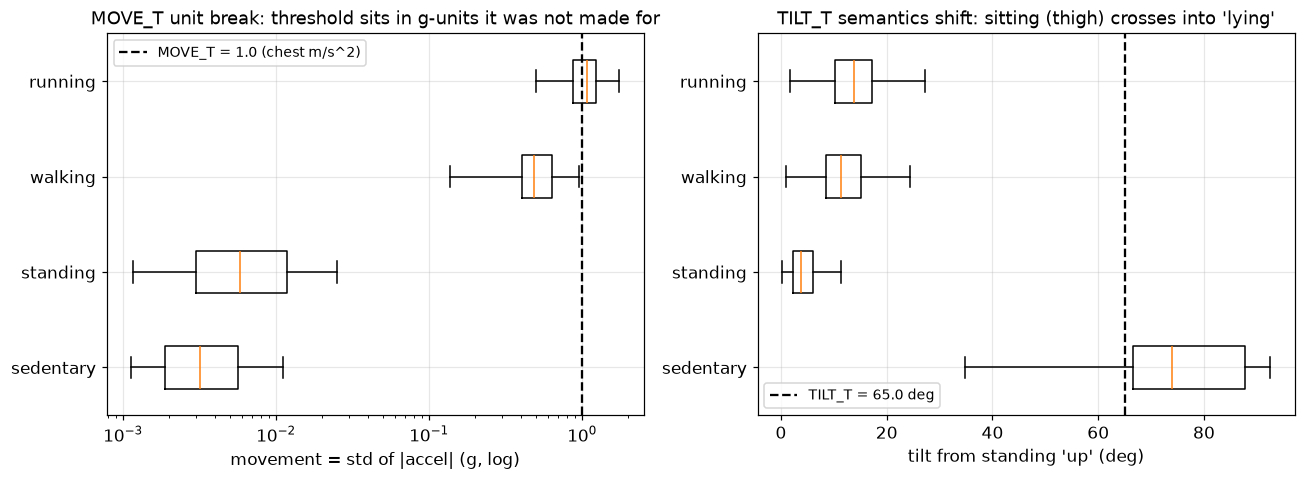

In [18]:
order = ["sedentary", "standing", "walking", "running"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].boxplot([PP.loc[PP.activity == a, "movement_g"].to_numpy() for a in order],
              orientation="horizontal", tick_labels=order, showfliers=False)
ax[0].axvline(MOVE_T, ls="--", color="black", label=f"MOVE_T = {MOVE_T} (chest m/s^2)")
ax[0].set_xscale("log"); ax[0].set_xlabel("movement = std of |accel| (g, log)")
ax[0].set_title("MOVE_T unit break: threshold sits in g-units it was not made for"); ax[0].legend(fontsize=9)

ax[1].boxplot([PP.loc[PP.activity == a, "tilt"].to_numpy() for a in order],
              orientation="horizontal", tick_labels=order, showfliers=False)
ax[1].axvline(TILT_T, ls="--", color="black", label=f"TILT_T = {TILT_T} deg")
ax[1].set_xlabel("tilt from standing 'up' (deg)")
ax[1].set_title("TILT_T semantics shift: sitting (thigh) crosses into 'lying'"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Scope note.** MotionSense has no lying activity, so postural's core distinction (lying vs upright, the largest orthostatic difference) is **untestable here**. What is observable is upright/in_motion behavior plus a *false* lying produced by sitting on the thigh. Lying-on-pocket is owed to own-phone data.

**Postural parameter ledger (this transfer):**
- calibration "up" (labeled standing) — *degraded*: stable per-subject but thigh-oriented; labeled standing is unavailable at runtime.
- `TILT_T = 65 deg` — *broke (semantics)*: measures thigh flexion on pocket; sitting reads as lying.
- `MOVE_T = 1.0` — *broke (units)*: g vs chest m/s^2; walking missed, running partial.

## v2.5 Cross-axis agreement (all three)
The integration payoff: align the three axes in time off one stream (postural and regularity share the 5 s window; `activity_state`'s 2.56 s window is mapped by majority overlap) and check the agreements that should hold. Every disagreement is flagged.

In [19]:
rows = []
for activity, subj, mag, total in streams3:
    if subj not in up_by_subj:
        continue
    up = up_by_subj[subj]
    AS = [(s, activity_rule(mag[s:s+AS_WINDOW].std(), mag[s:s+AS_WINDOW].mean(), as_cadence(mag[s:s+AS_WINDOW])))
          for s in range(0, len(mag) - AS_WINDOW + 1, AS_STEP)]
    for s in range(0, len(mag) - R_WINDOW + 1, R_STEP):
        _, score, _, reason = reg_emit_adapted(mag[s:s+R_WINDOW])
        _, _, verdict = window_posture(total[s:s+P_WINDOW], up)
        overlap = [p for st, p in AS if st < s + R_WINDOW and st + AS_WINDOW > s]
        as_label = max(set(overlap), key=overlap.count) if overlap else None
        rows.append((activity, as_label, reason, score, verdict))
X = pd.DataFrame(rows, columns=["true", "as_label", "reg_reason", "reg_score", "posture"])

print("activity_state label  x  postural verdict (counts):")
print(pd.crosstab(X["as_label"], X["posture"]).to_string())

mov = X[X.as_label.isin(["walking", "running"])]
sed = X[X.as_label == "sedentary"]
reg_hi = (mov.reg_reason == "valid") & (mov.reg_score >= 0.5)
print(f"\n[should hold] activity_state = walking/running ({len(mov)} windows):")
print(f"   regularity valid+regular (>=0.5): {reg_hi.mean()*100:.1f}%   -> AGREES motion is rhythmic")
print(f"   postural = in_motion           : {(mov.posture=='in_motion').mean()*100:.1f}%   -> DISAGREES (MOVE_T unit break); "
      f"{(mov.posture=='upright').mean()*100:.1f}% read upright")
print(f"\n[should hold] activity_state = sedentary ({len(sed)} windows):")
print(f"   regularity null low_movement    : {(sed.reg_reason=='low_movement').mean()*100:.1f}%   -> AGREES still")
print(f"   postural = upright              : {(sed.posture=='upright').mean()*100:.1f}%   "
      f"-> {(sed.posture=='lying').mean()*100:.1f}% DISAGREE as 'lying' (TILT_T thigh-flexion break)")
print("\nflagged disagreement source -- postural verdict by TRUE activity within activity_state=sedentary:")
print(pd.crosstab(sed["true"], sed["posture"]).to_string())
print("  (the 'lying' are all true sitting: thigh horizontal; true standing stays upright)")

activity_state label  x  postural verdict (counts):
posture    in_motion  lying  upright
as_label                            
running          158      0      154
sedentary          0    467      785
walking            0      0      621

[should hold] activity_state = walking/running (933 windows):
   regularity valid+regular (>=0.5): 90.4%   -> AGREES motion is rhythmic
   postural = in_motion           : 16.9%   -> DISAGREES (MOVE_T unit break); 83.1% read upright

[should hold] activity_state = sedentary (1252 windows):
   regularity null low_movement    : 97.4%   -> AGREES still
   postural = upright              : 62.7%   -> 37.3% DISAGREE as 'lying' (TILT_T thigh-flexion break)

flagged disagreement source -- postural verdict by TRUE activity within activity_state=sedentary:
posture    lying  upright
true                     
sedentary    467      130
standing       0      655
  (the 'lying' are all true sitting: thigh horizontal; true standing stays upright)


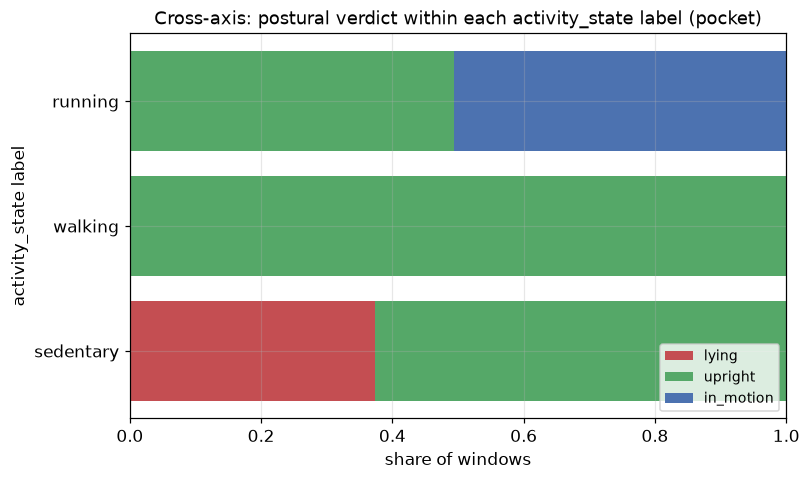

In [20]:
labels = ["sedentary", "walking", "running"]
comp = pd.crosstab(X["as_label"], X["posture"], normalize="index").reindex(index=labels, columns=POSTURE_CATEGORIES).fillna(0)
pcolor = {"lying": "#C44E52", "upright": "#55A868", "in_motion": "#4C72B0"}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
left = np.zeros(len(labels))
for p in POSTURE_CATEGORIES:
    ax.barh(labels, comp[p].to_numpy(), left=left, color=pcolor[p], label=p)
    left += comp[p].to_numpy()
ax.set_xlabel("share of windows"); ax.set_ylabel("activity_state label")
ax.set_title("Cross-axis: postural verdict within each activity_state label (pocket)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

## v2.6 Regression check (prior two axes)
Confirm that adding postural and sharing the front end changed nothing for `activity_state` and the normalized `movement_regularity`: both consume the unchanged `userAcceleration` magnitude, so their v1 results must reproduce exactly.

In [21]:
reg_med = X.dropna(subset=["reg_score"]).groupby("true")["reg_score"].median().round(3)
expected = {"walking": 0.711, "running": 0.656, "sedentary": 0.294, "standing": 0.314}   # v1 post-fix medians
print("movement_regularity adapted score medians (v2 shared front end vs v1 post-fix):")
ok = True
for a, e in expected.items():
    got = float(reg_med.get(a, np.nan))
    same = abs(got - e) < 1e-3
    ok &= same
    print(f"   {a:10s}: v2 {got:.3f}  v1 {e:.3f}  {'MATCH' if same else 'CHANGED'}")
print(f"   regularity regression: {'PASS' if ok else 'FAIL'}")

print("\nactivity_state confusion (true vs predicted) on shared front end:")
print(pd.crosstab(X["true"], X["as_label"]).to_string())
print("   standing folds into 'sedentary' by design; same structure as the v1 Part B sanity. No threshold recomputed.")

movement_regularity adapted score medians (v2 shared front end vs v1 post-fix):
   walking   : v2 0.711  v1 0.711  MATCH
   running   : v2 0.656  v1 0.656  MATCH
   sedentary : v2 0.294  v1 0.294  MATCH
   standing  : v2 0.314  v1 0.314  MATCH
   regularity regression: PASS

activity_state confusion (true vs predicted) on shared front end:
as_label   running  sedentary  walking
true                                  
running        258          0        5
sedentary        0        597        0
standing         0        655        0
walking         54          0      616
   standing folds into 'sedentary' by design; same structure as the v1 Part B sanity. No threshold recomputed.


## v2.7 Mechanics — three emissions off one stream
Confirm the three axes emit off one stream with separate `window_id`s and the correct HSI shapes (`activity_state` categorical, `movement_regularity` continuous, `postural_state` categorical). One combined example over the same time region is printed. Confidence: `movement_regularity` carries its deterministic confidence; `activity_state` confidence is margin_ref-based (train-derived) and not recomputed here; `postural_state` v1 emits none.

In [22]:
def reg_confidence(prom, ncyc):
    cyc = np.clip((ncyc - MIN_CYCLES_STRIDE) / (5.0 - MIN_CYCLES_STRIDE), 0.0, 1.0)   # stride-period adequacy
    prm = np.clip(prom / PROM_FULL, 0.0, 1.0)
    return float(np.sqrt(cyc * prm))

def reg_emit_full(window):
    bad = np.isnan(window) | (window > ACC_MAX)
    if bad.mean() > MAX_BAD_FRAC or bad[0]:
        return dict(score=np.nan, prom=0.0, ncyc=0.0, reason="window_unreliable")
    mag = fill_gaps(window, bad); movement = float(mag.std())
    x = mag - mag.mean(); n = len(x)
    ac = np.correlate(x, x, mode="full")[n-1:n+LAG_MAX] / (n - np.arange(LAG_MAX + 1))
    if ac[0] <= 0:
        return dict(score=np.nan, prom=0.0, ncyc=0.0, reason="window_unreliable")
    ac = ac / ac[0]
    lag = LAG_MIN + int(np.argmax(ac[LAG_MIN:LAG_MAX + 1])); score = float(np.clip(ac[lag], 0, 1))
    peaks, props = find_peaks(ac, prominence=PEAK_PROMINENCE)
    prom = float(props["prominences"][list(peaks).index(lag)]) if lag in list(peaks) else 0.0
    ncyc = R_WINDOW / lag
    reason = "low_movement" if movement < MOVEMENT_FLOOR_G else ("insufficient_cycles" if ncyc < MIN_CYCLES_STRIDE else "valid")
    return dict(score=score, prom=prom, ncyc=ncyc, reason=reason)

# HSI emitters (shapes verbatim from each axis; postural mirrors activity_state's categorical shape)
def emit_activity(label, wid):
    return {"name": "activity_state", "score": None, "label": label, "categories": HSI_CATEGORIES,
            "confidence": None, "direction": "categorical", "inference_mode": "deterministic_rule",
            "model_id": "rulepack://activity_state_v1", "window_id": wid}
def emit_regularity(d, wid):
    valid = d["reason"] == "valid"
    return {"name": "movement_regularity", "score": round(d["score"], 3) if valid else None,
            "direction": "higher_is_more", "confidence": round(reg_confidence(d["prom"], d["ncyc"]), 3) if valid else None,
            "reason": None if valid else d["reason"], "inference_mode": "deterministic_rule",
            "model_id": "rulepack://movement_regularity_v1", "window_id": wid}
def emit_posture(label, wid):
    return {"name": "postural_state", "score": None, "label": label, "categories": POSTURE_CATEGORIES,
            "confidence": None, "direction": "categorical", "inference_mode": "deterministic_rule",
            "model_id": "rulepack://postural_state_v1", "window_id": wid}

# one time region of a held-out walking stream: same samples, three readings
activity, subj, mag, total = next(s for s in streams3 if s[0] == "walking" and s[1] in up_by_subj)
up = up_by_subj[subj]; s0 = R_STEP * 4                                  # an arbitrary aligned start
sid = f"sub{subj}:{activity}"
as_lab = activity_rule(mag[s0:s0+AS_WINDOW].std(), mag[s0:s0+AS_WINDOW].mean(), as_cadence(mag[s0:s0+AS_WINDOW]))
rg = reg_emit_full(mag[s0:s0+R_WINDOW])
_, _, pv = window_posture(total[s0:s0+P_WINDOW], up)
combined = [emit_activity(as_lab, f"{sid}#act@{s0}-{s0+AS_WINDOW}"),
            emit_regularity(rg, f"{sid}#reg@{s0}-{s0+R_WINDOW}"),
            emit_posture(pv, f"{sid}#pos@{s0}-{s0+P_WINDOW}")]
print(f"one stream ({sid}), one time region, three readings with separate window_ids:")
print(json.dumps(combined, indent=2))
print("\nshapes OK: activity_state categorical (label), movement_regularity continuous (score+direction),",
      "postural_state categorical (label); window_ids distinct.")
print(f"note: this region shows the live cross-axis disagreement -- activity_state='{as_lab}', postural='{pv}' (MOVE_T break).")

one stream (sub23:walking), one time region, three readings with separate window_ids:
[
  {
    "name": "activity_state",
    "score": null,
    "label": "walking",
    "categories": [
      "sedentary",
      "standing",
      "walking",
      "running",
      "cycling",
      "vigorous"
    ],
    "confidence": null,
    "direction": "categorical",
    "inference_mode": "deterministic_rule",
    "model_id": "rulepack://activity_state_v1",
    "window_id": "sub23:walking#act@500-628"
  },
  {
    "name": "movement_regularity",
    "score": 0.61,
    "direction": "higher_is_more",
    "confidence": 0.705,
    "reason": null,
    "inference_mode": "deterministic_rule",
    "model_id": "rulepack://movement_regularity_v1",
    "window_id": "sub23:walking#reg@500-750"
  },
  {
    "name": "postural_state",
    "score": null,
    "label": "upright",
    "categories": [
      "lying",
      "upright",
      "in_motion"
    ],
    "confidence": null,
    "direction": "categorical",
    "infer

## v2.8 Transfer ledger v2
One row per parameter across the three axes. Survived / degraded / broke / untestable, with the fix a future per-placement-normalization loop must address. Two distinct "owed to own-phone data" lines are kept: regularity spectrum-on-pocket, and postural lying-on-pocket. Nothing is fixed here.

In [23]:
ledger = pd.DataFrame([
    ["T_STILL / T_RUN / cadence split",      "activity_state",      "survived",          "derived on MotionSense; home turf, not an out-of-placement test",                       "no"],
    ["MOVEMENT_FLOOR_G + argmax period + MIN_CYCLES_STRIDE", "movement_regularity", "survived", "pocket-normalized in v1 convergence; score rank-ordering reproduced exactly (v2.6)",     "no"],
    ["calibration 'up' (labeled standing)",  "postural_state",      "degraded",          "per-subject up stable (within-standing few deg) but thigh-oriented; cross-subject 4-25 deg; labeled standing absent at runtime", "yes: walking-reference calibration"],
    ["TILT_T = 65 deg",                      "postural_state",      "broke (semantics)", "thigh angle != torso: sitting ~74 deg -> 'lying'; standing ~4 deg; tilt now splits sit/stand, not lie/upright", "yes: per-placement tilt model"],
    ["MOVE_T = 1.0 (chest m/s^2)",           "postural_state",      "broke (units)",     "g-scale movement: walking ~0.49 g (0% in_motion), running ~1.08 g (~60%); needs ~0.10 g",  "yes: unit conversion"],
    ["lying vs upright (postural core)",     "postural_state",      "untestable here",   "MotionSense has no lying; also surfaces false-lying from sitting",                       "owed: own-phone data"],
    ["spectrum on pocket (rhythmic vs irregular motion)", "movement_regularity", "untestable here", "MotionSense has no irregular-but-moving activity; only rhythmic > still shown",          "owed: own-phone data"],
], columns=["param", "axis", "status", "note", "fix_next"])
print(ledger.to_string(index=False))

                                               param                axis            status                                                                                                                           note                           fix_next
                     T_STILL / T_RUN / cadence split      activity_state          survived                                                                derived on MotionSense; home turf, not an out-of-placement test                                 no
MOVEMENT_FLOOR_G + argmax period + MIN_CYCLES_STRIDE movement_regularity          survived                                             pocket-normalized in v1 convergence; score rank-ordering reproduced exactly (v2.6)                                 no
                 calibration 'up' (labeled standing)      postural_state          degraded per-subject up stable (within-standing few deg) but thigh-oriented; cross-subject 4-25 deg; labeled standing absent at runtime yes: walking-reference 

### Findings v2
- **Three axes run off one shared front end** with separate window_ids and correct HSI shapes (categorical / continuous / categorical); the combined example shows all three reading the same time region.
- **Postural calibration on pocket is sensible only per-subject.** The standing "up" vector is stable within a subject (within-standing spread a few degrees) but varies 4-25 deg across subjects: it points along the thigh, not the torso. A global "up" is not recoverable, and labeled-standing calibration is unavailable at runtime — walking-reference calibration (with `activity_state` flagging walking) is the owed fix.
- **`TILT_T = 65 deg` broke in meaning, not just value.** On the thigh, sitting flexes ~74 deg and is read as `lying` (a false lying, with no real lying in the data); standing stays ~4 deg / upright. The tilt axis now separates sit vs stand (thigh flexion) — the very distinction it could not make on the chest — while lie-vs-upright (its chest strength) is untestable here. The axis has effectively rotated meaning across placement.
- **`MOVE_T = 1.0` broke on units** (chest m/s^2 vs g), the same class of break logged for `MOVEMENT_FLOOR` in v1: walking movement ~0.49 g never crosses 1.0 (0% `in_motion`), running ~1.08 g crosses about 60%. In g the threshold should be ~0.10.
- **Cross-axis disagreements the integration reveals:** where `activity_state` says walking/running, `movement_regularity` agrees it is rhythmic (~90% valid+regular) but `postural_state` says `upright` instead of `in_motion` (MOVE_T break). Where `activity_state` says sedentary, regularity agrees it is still (~97% `low_movement`) but postural calls ~37% `lying` — all of them true sitting (thigh-flexion break). These are single-axis bugs only co-emission surfaces.
- **No regression on the prior two axes:** `movement_regularity` score medians reproduce v1 exactly (walking 0.711, running 0.656, sedentary 0.294, standing 0.314) and `activity_state` keeps its v1 structure. Sharing the front end and adding postural changed nothing — postural consumes a separate reconstructed-gravity stream.
- **Two distinct debts owed to own-phone data:** regularity spectrum-on-pocket (rhythmic vs irregular motion) and postural lying-on-pocket. Both remain separate ledger lines. Nothing was re-tuned; a future per-placement-normalization loop must convert `MOVE_T` to g, replace labeled-standing calibration with a walking reference, and rebuild the tilt model for the thigh (or fold sit/stand recovery into it).

# Postural_state — thigh/pocket rework (convergence-only)

The chest `postural_state.ipynb` stays **frozen** (chest proof-of-method, untouched). The v2 test above showed the chest rule breaks on the thigh; here it is rebuilt for thigh placement inside the convergence notebook only.

The chest model separates lying-vs-upright and merges sit/stand (~4.3 deg apart). On the thigh the geometry inverts: sitting flexes the thigh (~74 deg), standing keeps it vertical (~4 deg), so **sit-vs-stand becomes cleanly separable by tilt** while lying becomes the hard case. Three distinct changes, kept separate in the findings:
1. **MOVE_T unit fix** (trivial) — chest m/s^2 -> g. *Validated here.*
2. **Thigh tilt model** — sit-vs-stand boundary derived from MotionSense's own sit/standing tilt, not the chest 65 deg line. *Validated here.*
3. **Lying branch** — flat AND alive = lying; flat AND dead-still = `device_resting` (phone on a surface), not a posture. *Implemented only — MotionSense has no lying and no phone-on-table data, so it is UNTESTED.*

Output classes on the thigh: `standing` / `sitting` / `in_motion` (validated) and `lying` / `device_resting` (implemented, untested). Everything else frozen; subject-independent; reuses the v2 shared front end (`streams3`) and per-subject calibration (`up_by_subj`).

## P.1 Setup — reuse v2 front end, thigh constants
The reconstructed-gravity stream and per-subject "up" come from v2; only the postural decision is reworked. `MOVE_T_G` is the unit-converted gate; `FLAT_T` and `MICRO_FLOOR_G` are flagged placeholders for the untested lying branch; `SIT_STAND_T` is derived from data in P.3.

In [24]:
assert "streams3" in dir() and "up_by_subj" in dir() and "tilt_angle" in dir(), "run the v2 cells above first"

# CHANGE 1: MOVE_T unit fix -- chest m/s^2 -> g (frozen MOVE_T reused, only the units corrected)
MOVE_T_G = MOVE_T / 9.81                 # ~0.102 g
# CHANGE 3 placeholders (UNTESTED -- no lying / no phone-on-table data in MotionSense)
FLAT_T = 85.0                            # tilt (deg) at/above which the thigh is "flat" (near horizontal)
MICRO_FLOOR_G = 0.002                    # movement (g) below which a flat window is a dead device, not a body
# CHANGE 2: derived from data in P.3 (placeholder until then)
SIT_STAND_T = None

THIGH_CATEGORIES = ["standing", "sitting", "in_motion", "lying", "device_resting"]

# per-window thigh features off the v2 stream (movement in g, tilt vs per-subject standing 'up')
trows = []
for activity, subj, mag, total in streams3:
    if subj not in up_by_subj:
        continue
    up = up_by_subj[subj]
    for s in range(0, len(total) - P_WINDOW + 1, P_STEP):
        w = total[s:s + P_WINDOW]
        mv = float(np.sqrt((w ** 2).sum(axis=1)).std())
        tl = float(tilt_angle(w.mean(axis=0), up))
        trows.append((activity, subj, mv, tl))
PT = pd.DataFrame(trows, columns=["activity", "subject", "movement_g", "tilt"])
print(f"thigh windows: {len(PT)}  |  MOVE_T_G = {MOVE_T_G:.4f} g (was {MOVE_T} chest m/s^2)")

thigh windows: 2185  |  MOVE_T_G = 0.1019 g (was 1.0 chest m/s^2)


## P.2 Change 1 — MOVE_T unit fix (validated)
Converting the gate to g should make walking and running fire `in_motion` (v2 missed walking entirely) while static postures stay below it.

In [25]:
fire = (PT.groupby("activity")["movement_g"].apply(lambda x: (x > MOVE_T_G).mean()) * 100).round(1)
print(f"in_motion firing rate per activity at MOVE_T_G = {MOVE_T_G:.3f} g:")
print(fire.to_string())
print(f"\nVALIDATED: walking {fire['walking']:.0f}% and running {fire['running']:.0f}% now fire in_motion "
      f"(v2 frozen chest threshold: walking 0%); standing {fire['standing']:.0f}% / sitting {fire['sedentary']:.0f}% stay static.")

in_motion firing rate per activity at MOVE_T_G = 0.102 g:
activity
running      100.0
sedentary      0.0
standing       0.0
walking      100.0

VALIDATED: walking 100% and running 100% now fire in_motion (v2 frozen chest threshold: walking 0%); standing 0% / sitting 0% stay static.


## P.3 Change 2 — thigh tilt model, sit vs stand (validated)
The boundary is read off MotionSense's actual standing and sitting tilt distributions (held-out subjects), not the chest 65 deg line. Calibration "up" is the per-subject standing gravity vector (still labeled-standing; the runtime fix is walking-reference calibration, deferred).

In [26]:
static = PT[PT.movement_g <= MOVE_T_G]
stand = static.loc[static.activity == "standing", "tilt"]
sit = static.loc[static.activity == "sedentary", "tilt"]          # MotionSense 'sit' = sitting

# derive the boundary from the gap between the two distributions (not accuracy-fit, not the chest line)
gap_lo, gap_hi = stand.quantile(.95), sit.quantile(.05)
SIT_STAND_T = float(round((gap_lo + gap_hi) / 2))
print(f"standing thigh tilt: median {stand.median():.1f} deg, p95 {gap_lo:.1f} deg  (vertical)")
print(f"sitting  thigh tilt: median {sit.median():.1f} deg, p05 {gap_hi:.1f} deg  (flexed)")
print(f"clean gap [{gap_lo:.1f}, {gap_hi:.1f}] -> SIT_STAND_T = midpoint = {SIT_STAND_T:.0f} deg (chest line was 65)")

ss = static[static.activity.isin(["standing", "sedentary"])].copy()
ss["true"] = ss.activity.map({"standing": "standing", "sedentary": "sitting"})
ss["pred"] = np.where(ss.tilt < SIT_STAND_T, "standing", "sitting")
print(f"\nVALIDATED sit-vs-stand accuracy @ {SIT_STAND_T:.0f} deg: {(ss.true == ss.pred).mean()*100:.1f}%  (n={len(ss)}, held-out)")
print("   robustness (accuracy vs boundary):",
      {t: round((np.where(ss.tilt < t, 'standing', 'sitting') == ss.true.values).mean()*100, 1) for t in [20, 25, 30]})

ks = sorted(up_by_subj)
cross = [tilt_angle(up_by_subj[ks[i]], up_by_subj[ks[j]]) for i in range(len(ks)) for j in range(i+1, len(ks))]
print(f"calibration 'up' cross-subject angle: median {np.median(cross):.1f} deg, range {min(cross):.1f}-{max(cross):.1f} deg "
      f"(thigh-oriented; per-subject self-calibration, not a shared vector)")

standing thigh tilt: median 3.8 deg, p95 11.7 deg  (vertical)
sitting  thigh tilt: median 73.9 deg, p05 37.8 deg  (flexed)
clean gap [11.7, 37.8] -> SIT_STAND_T = midpoint = 25 deg (chest line was 65)

VALIDATED sit-vs-stand accuracy @ 25 deg: 100.0%  (n=1252, held-out)
   robustness (accuracy vs boundary): {20: np.float64(100.0), 25: np.float64(100.0), 30: np.float64(100.0)}
calibration 'up' cross-subject angle: median 8.5 deg, range 2.1-24.5 deg (thigh-oriented; per-subject self-calibration, not a shared vector)


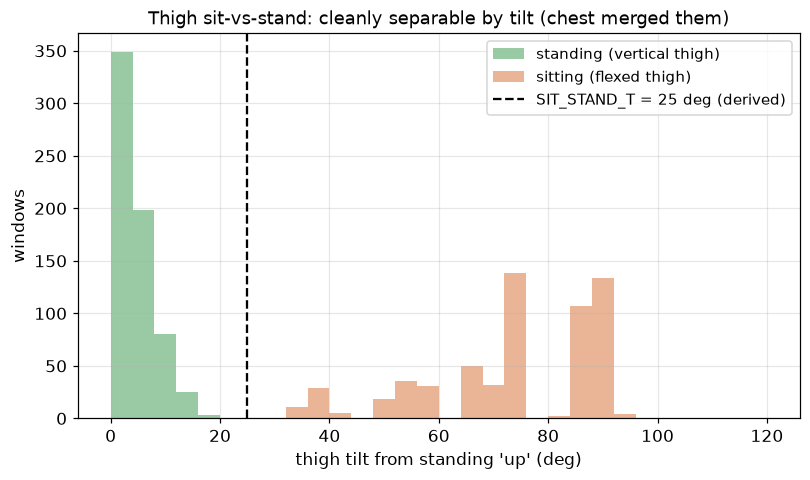

In [27]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(stand, bins=np.arange(0, 121, 4), alpha=0.6, color="#55A868", label="standing (vertical thigh)")
ax.hist(sit, bins=np.arange(0, 121, 4), alpha=0.6, color="#DD8452", label="sitting (flexed thigh)")
ax.axvline(SIT_STAND_T, ls="--", color="black", label=f"SIT_STAND_T = {SIT_STAND_T:.0f} deg (derived)")
ax.set_xlabel("thigh tilt from standing 'up' (deg)"); ax.set_ylabel("windows")
ax.set_title("Thigh sit-vs-stand: cleanly separable by tilt (chest merged them)")
ax.legend()
plt.tight_layout(); plt.show()

## P.4 Change 3 — lying / device_resting branch (implemented, UNTESTED)
The full thigh rule. A flat window (tilt at/above `FLAT_T`) is `lying` only if it also carries micro-movement (a live body); flat and dead-still is `device_resting` (a phone on a surface), not a posture. **MotionSense has no lying and no phone-on-table data, so this branch cannot be validated here** — no lying accuracy is claimed. On real data it only relabels sitting's near-horizontal tail, which itself shows the unresolved sit/lying tilt overlap; a synthetic check confirms the logic fires correctly.

In [28]:
def thigh_posture(movement_g, tilt):
    """Thigh postural verdict. movement_g in g, tilt in deg from the subject's standing 'up'."""
    if movement_g > MOVE_T_G:                 # CHANGE 1
        return "in_motion"
    if tilt < SIT_STAND_T:                     # CHANGE 2 (validated)
        return "standing"
    if tilt < FLAT_T:
        return "sitting"
    # flat (near horizontal) -- CHANGE 3, UNTESTED
    return "device_resting" if movement_g < MICRO_FLOOR_G else "lying"

PT["verdict"] = [thigh_posture(m, t) for m, t in zip(PT.movement_g, PT.tilt)]
print("full thigh verdict per activity (share of windows):")
print(pd.crosstab(PT.activity, PT.verdict, normalize="index").round(3).to_string())

leak = (sit >= FLAT_T).mean() * 100
print(f"\nUNTESTED-overlap note: {leak:.0f}% of sitting windows have tilt >= FLAT_T ({FLAT_T:.0f} deg) and fall into the flat branch.")
print("   sitting's thigh tilt tail reaches horizontal, so sit and lying overlap -> no clean FLAT_T from this data.")
print(f"   device_resting on MotionSense body data: {(PT.verdict=='device_resting').sum()} windows "
      f"(still-sitting tail; no real phone-on-table data exists here).")

# synthetic check: the branch produces the right verdict given separable inputs
rng = np.random.default_rng(0); up = np.array([0., 1., 0.])
flat_dir = np.array([0., np.cos(np.radians(88)), np.sin(np.radians(88))])     # ~88 deg from 'up' (horizontal)
print("\nsynthetic check (proves the lying/device logic runs; not validation):")
for name, noise in [("phone on table", 0.0008), ("lying body (breathing)", 0.02)]:
    w = flat_dir + rng.normal(0, noise, (P_WINDOW, 3))
    mv = float(np.sqrt((w ** 2).sum(axis=1)).std()); tl = float(tilt_angle(w.mean(axis=0), up))
    print(f"   {name:22s}: movement {mv:.4f} g, tilt {tl:.0f} deg -> {thigh_posture(mv, tl)}")

full thigh verdict per activity (share of windows):
verdict    device_resting  in_motion  lying  sitting  standing
activity                                                      
running             0.000        1.0  0.000     0.00       0.0
sedentary           0.032        0.0  0.308     0.66       0.0
standing            0.000        0.0  0.000     0.00       1.0
walking             0.000        1.0  0.000     0.00       0.0

UNTESTED-overlap note: 34% of sitting windows have tilt >= FLAT_T (85 deg) and fall into the flat branch.
   sitting's thigh tilt tail reaches horizontal, so sit and lying overlap -> no clean FLAT_T from this data.
   device_resting on MotionSense body data: 19 windows (still-sitting tail; no real phone-on-table data exists here).

synthetic check (proves the lying/device logic runs; not validation):
   phone on table        : movement 0.0008 g, tilt 88 deg -> device_resting
   lying body (breathing): movement 0.0213 g, tilt 88 deg -> lying


## P.5 Cross-axis recheck — does the rework resolve the v2 disagreements?
v2 flagged: where `activity_state` said walking/running, postural wrongly said `upright`; where it said sedentary, postural wrongly said `lying`. Re-run the three-axis alignment with the thigh rule (validated classes only).

In [29]:
rows = []
for activity, subj, mag, total in streams3:
    if subj not in up_by_subj:
        continue
    up = up_by_subj[subj]
    AS = [(s, activity_rule(mag[s:s+AS_WINDOW].std(), mag[s:s+AS_WINDOW].mean(), as_cadence(mag[s:s+AS_WINDOW])))
          for s in range(0, len(mag) - AS_WINDOW + 1, AS_STEP)]
    for s in range(0, len(mag) - R_WINDOW + 1, R_STEP):
        _, score, _, reason = reg_emit_adapted(mag[s:s+R_WINDOW])
        w = total[s:s+P_WINDOW]
        verdict = thigh_posture(float(np.sqrt((w**2).sum(axis=1)).std()), float(tilt_angle(w.mean(axis=0), up)))
        overlap = [p for st, p in AS if st < s + R_WINDOW and st + AS_WINDOW > s]
        as_label = max(set(overlap), key=overlap.count) if overlap else None
        rows.append((activity, as_label, reason, score, verdict))
XT = pd.DataFrame(rows, columns=["true", "as_label", "reg_reason", "reg_score", "posture"])

mov = XT[XT.as_label.isin(["walking", "running"])]
sed = XT[XT.as_label == "sedentary"]
print(f"activity_state = walking/running ({len(mov)}): postural in_motion {(mov.posture=='in_motion').mean()*100:.1f}% "
      f"(v2 was 16.9%) -> now AGREES with activity_state and regularity")
print(f"activity_state = sedentary ({len(sed)}): postural standing/sitting "
      f"{(sed.posture.isin(['standing','sitting'])).mean()*100:.1f}% (the validated static classes); "
      f"lying/device {(sed.posture.isin(['lying','device_resting'])).mean()*100:.1f}% (untested-branch artifact on sitting's flat tail)")
print("\nactivity_state label x thigh postural verdict:")
print(pd.crosstab(XT.as_label, XT.posture).reindex(columns=THIGH_CATEGORIES, fill_value=0).to_string())

activity_state = walking/running (933): postural in_motion 100.0% (v2 was 16.9%) -> now AGREES with activity_state and regularity
activity_state = sedentary (1252): postural standing/sitting 83.8% (the validated static classes); lying/device 16.2% (untested-branch artifact on sitting's flat tail)

activity_state label x thigh postural verdict:
posture    standing  sitting  in_motion  lying  device_resting
as_label                                                      
running           0        0        312      0               0
sedentary       655      394          0    184              19
walking           0        0        621      0               0


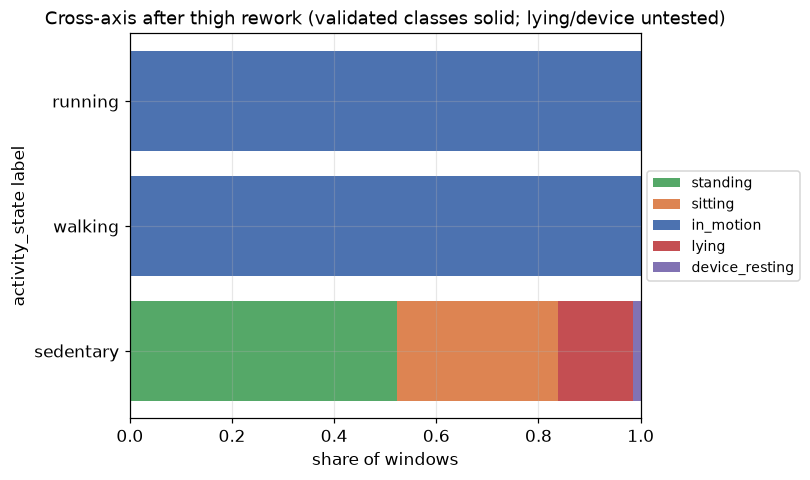

In [30]:
labels = ["sedentary", "walking", "running"]
comp = pd.crosstab(XT.as_label, XT.posture, normalize="index").reindex(index=labels, columns=THIGH_CATEGORIES).fillna(0)
pcolor = {"standing": "#55A868", "sitting": "#DD8452", "in_motion": "#4C72B0", "lying": "#C44E52", "device_resting": "#8172B3"}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
left = np.zeros(len(labels))
for p in THIGH_CATEGORIES:
    ax.barh(labels, comp[p].to_numpy(), left=left, color=pcolor[p], label=p)
    left += comp[p].to_numpy()
ax.set_xlabel("share of windows"); ax.set_ylabel("activity_state label")
ax.set_title("Cross-axis after thigh rework (validated classes solid; lying/device untested)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout(); plt.show()

## P.6 Ledger update — thigh model supersedes the chest TILT_T for pocket

In [31]:
thigh_ledger = pd.DataFrame([
    ["MOVE_T -> MOVE_T_G (g)",        "postural / thigh", "fixed (validated)",        f"chest m/s^2 -> {MOVE_T_G:.3f} g; walking/running now 100% in_motion, static 0%",        "no"],
    ["chest TILT_T = 65 deg",         "postural / thigh", "replaced",                 "superseded on pocket by the thigh tilt model; chest line not used for pocket",            "no"],
    ["SIT_STAND_T = 25 deg",          "postural / thigh", "new (validated)",          "derived from held-out sit/standing thigh tilt (gap 12-38 deg); sit-vs-stand 100%",        "calibration still labeled-standing"],
    ["calibration 'up' (standing)",   "postural / thigh", "degraded (carried)",       "per-subject stable, cross-subject 2-25 deg (thigh); labeled-standing absent at runtime",  "yes: walking-reference calibration"],
    ["FLAT_T / MICRO_FLOOR_G (lying/device)", "postural / thigh", "implemented, untested", "sit/lying thigh tilt overlaps (~34% of sitting >= FLAT_T) and no phone-on-table data; synthetic-only", "owed: own-phone data"],
    ["lying-on-pocket",               "postural / thigh", "owed (carried)",           "no lying in MotionSense; sit/lying tilt overlap unresolvable here",                        "owed: own-phone data"],
    ["spectrum on pocket (regularity)","movement_regularity", "owed (carried from v2)", "no irregular-but-moving activity in MotionSense",                                          "owed: own-phone data"],
], columns=["param", "axis", "status", "note", "fix_next"])
print(thigh_ledger.to_string(index=False))

                                param                axis                 status                                                                                                 note                           fix_next
               MOVE_T -> MOVE_T_G (g)    postural / thigh      fixed (validated)                                chest m/s^2 -> 0.102 g; walking/running now 100% in_motion, static 0%                                 no
                chest TILT_T = 65 deg    postural / thigh               replaced                         superseded on pocket by the thigh tilt model; chest line not used for pocket                                 no
                 SIT_STAND_T = 25 deg    postural / thigh        new (validated)                     derived from held-out sit/standing thigh tilt (gap 12-38 deg); sit-vs-stand 100% calibration still labeled-standing
          calibration 'up' (standing)    postural / thigh     degraded (carried)               per-subject stable, cross-subject 2-2

### Findings — thigh/pocket rework

**Validated here (sit/stand + MOVE_T):**
- **MOVE_T unit fix works.** Converting the chest gate to g (`MOVE_T_G` ~ 0.102) makes walking and running fire `in_motion` at 100% (v2 frozen chest threshold missed walking entirely), while standing and sitting stay static (0%).
- **Thigh tilt model separates sit from stand cleanly.** Standing thigh tilt is ~4 deg (vertical) and sitting ~74 deg (flexed), with a wide empty gap (12-38 deg). The boundary `SIT_STAND_T = 25 deg`, read off the held-out distributions (not the chest 65 deg line), gives **100% sit-vs-stand accuracy**, stable across 20-30 deg. This is the exact distinction the chest model could not make (sit/stand merged at ~4.3 deg) — placement inverts which postures are separable.
- **Calibration "up"** is the per-subject standing gravity vector: stable within a subject but thigh-oriented (cross-subject 2-25 deg), so it is a self-calibration, not a shared vector. It still relies on labeled standing; the runtime fix (walking-reference calibration via `activity_state`) is deferred.
- **Cross-axis disagreements from v2 resolved for the validated classes:** where `activity_state` says walking/running, postural now says `in_motion` (was `upright`); where it says sedentary, postural returns the static classes instead of the v2 false-`lying`.

**Implemented only — UNTESTED (lying + device_resting):**
- The lying branch (flat AND alive) and `device_resting` (flat AND dead-still) are implemented and shown to fire correctly on a synthetic phone-on-table vs breathing-body check, but **cannot be validated**: MotionSense has no lying and no phone-on-table data. No lying accuracy is claimed.
- On real data the branch only relabels sitting's near-horizontal tail (~34% of sitting windows reach tilt >= `FLAT_T`), which surfaces the deeper problem: **sitting and lying overlap in thigh tilt** (both go horizontal), so no clean `FLAT_T` can be drawn from this dataset. `FLAT_T` and `MICRO_FLOOR_G` are flagged placeholders.
- **Owed to own-phone data:** lying-on-pocket (real lying + phone-on-table to set `FLAT_T` and `MICRO_FLOOR_G` and to separate sit from lying), kept as a distinct ledger line alongside the regularity spectrum-on-pocket debt from v2.
- Frozen otherwise; subject-independent; the chest `postural_state.ipynb` and the other axis notebooks are untouched.